In [3]:
import os, json
import numpy as np
import pandas as pd
import cv2


def collect_arena_roi_opencv(video_path, roi_json_path):
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise RuntimeError(f"Could not read first frame from: {video_path}")

    points = []
    window = "Arena ROI (L-click add, R-click undo, 's' save, 'q' quit)"

    def redraw(img, pts):
        out = img.copy()
        for (x, y) in pts:
            cv2.circle(out, (x, y), 4, (255, 0, 0), -1)
        if len(pts) >= 2:
            p = np.array(pts, np.int32).reshape((-1, 1, 2))
            cv2.polylines(out, [p], False, (0, 255, 0), 2)
        cv2.putText(out, f"Points: {len(pts)}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)
        return out

    display = redraw(frame, points)

    def on_mouse(event, x, y, flags, param):
        nonlocal points, display
        if event == cv2.EVENT_LBUTTONDOWN:
            points.append((int(x), int(y)))
            display = redraw(frame, points)
        elif event == cv2.EVENT_RBUTTONDOWN:
            if points:
                points.pop()
                display = redraw(frame, points)

    cv2.namedWindow(window, cv2.WINDOW_NORMAL)
    cv2.setMouseCallback(window, on_mouse)

    while True:
        cv2.imshow(window, display)
        key = cv2.waitKey(20) & 0xFF

        if key == ord('s'):
            if len(points) < 3:
                print("Need at least 3 points to save a polygon.")
                continue
            with open(roi_json_path, "w") as f:
                json.dump(points, f)
            print("Saved ROI:", roi_json_path)
            break

        if key == ord('q') or key == 27:
            cv2.destroyAllWindows()
            raise RuntimeError("Quit without saving ROI.")

    cv2.destroyAllWindows()
    return frame, points


def load_or_create_arena_mask(video_path, roi_json_path=None):
    if roi_json_path is None:
        roi_json_path = os.path.splitext(video_path)[0] + "_arena_roi.json"

    if os.path.exists(roi_json_path):
        with open(roi_json_path, "r") as f:
            arena_points = json.load(f)

        cap = cv2.VideoCapture(video_path)
        ret, frame0 = cap.read()
        cap.release()
        if not ret:
            raise RuntimeError(f"Could not read first frame from: {video_path}")

        print("Loaded ROI:", roi_json_path)
    else:
        frame0, arena_points = collect_arena_roi_opencv(video_path, roi_json_path)

    H, W = frame0.shape[:2]
    pts = np.array(arena_points, dtype=np.int32).reshape((-1, 1, 2))

    arena_mask = np.zeros((H, W), dtype=np.uint8)
    cv2.fillPoly(arena_mask, [pts], 255)

    return arena_mask, H, W, roi_json_path


def arena_mask_and_filter_positions(
    pose_csv_or_df,
    video_path,
    roi_json_path=None,
    ref_x="ear_mid_x",
    ref_y="ear_mid_y",
    pose_cols=None,
    add_in_arena_col=True,
    out_csv_path=None,
):
    """
    Creates/loads an arena mask from video ROI, then NaN-outs pose columns
    for rows whose (ref_x, ref_y) are outside the mask.

    pose_csv_or_df:
      - str path to CSV, OR a pandas DataFrame

    pose_cols:
      - list of columns to NaN-out when outside
      - if None, defaults to your usual pose set
    """

    # --- load df ---
    if isinstance(pose_csv_or_df, str):
        df = pd.read_csv(pose_csv_or_df)
    else:
        df = pose_csv_or_df.copy()

    if pose_cols is None:
        pose_cols = [
            "nose.x","nose.y",
            "ear_L.x","ear_L.y",
            "ear_R.x","ear_R.y",
            "ear_mid_x","ear_mid_y"
        ]

    # --- build/load arena mask ---
    arena_mask, H, W, roi_path_used = load_or_create_arena_mask(video_path, roi_json_path=roi_json_path)

    # --- compute inside/outside using ref point ---
    xs = df[ref_x].to_numpy()
    ys = df[ref_y].to_numpy()

    inside = np.zeros(len(df), dtype=bool)

    valid = np.isfinite(xs) & np.isfinite(ys)
    xi = xs[valid].astype(int)
    yi = ys[valid].astype(int)

    in_bounds = (xi >= 0) & (xi < W) & (yi >= 0) & (yi < H)
    valid_idx = np.where(valid)[0][in_bounds]

    inside[valid_idx] = arena_mask[yi[in_bounds], xi[in_bounds]] > 0

    if add_in_arena_col:
        df["in_arena"] = inside

    # --- NaN out pose cols outside arena ---
    existing_pose_cols = [c for c in pose_cols if c in df.columns]
    df.loc[~inside, existing_pose_cols] = np.nan

    # --- optional save ---
    if out_csv_path is not None:
        df.to_csv(out_csv_path, index=False)

    return df, arena_mask, roi_path_used

In [4]:
filtered_df, arena_mask, roi_path = arena_mask_and_filter_positions(
    pose_csv_or_df=r"C:\Users\psych-aalab\Desktop\zenon_frametest\20251028\1028_dataloader_HDcalc.csv",
    video_path=r"C:\Users\psych-aalab\Desktop\zenon_frametest\20251028\20251028_behcam.avi",
    ref_x="ear_mid_x",
    ref_y="ear_mid_y",
    out_csv_path=r"C:\Users\psych-aalab\Desktop\aligned_minimal_arena_filtered.csv"
)

print("ROI used:", roi_path)
print("Filtered rows outside arena:", (~filtered_df["in_arena"]).sum())

Saved ROI: C:\Users\psych-aalab\Desktop\zenon_frametest\20251028\20251028_behcam_arena_roi.json
ROI used: C:\Users\psych-aalab\Desktop\zenon_frametest\20251028\20251028_behcam_arena_roi.json
Filtered rows outside arena: 33002


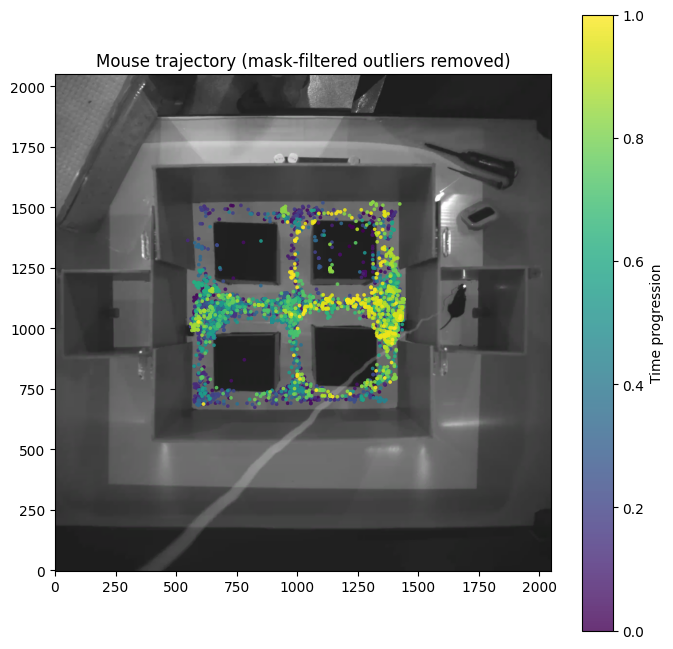

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- choose which point to plot ---
x_col = "ear_mid_x"
y_col = "ear_mid_y"

# --- load first frame of arena video as background ---
beh_video_path = r"C:\Users\psych-aalab\Desktop\zenon_frametest\20251028\20251028_behcam.avi"
cap = cv2.VideoCapture(beh_video_path)
ret, frame = cap.read()
cap.release()
if not ret:
    raise RuntimeError(f"Could not read first frame from: {beh_video_path}")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# --- pull filtered positions (outside-mask rows are NaN) ---
xs = filtered_df[x_col].to_numpy()
ys = filtered_df[y_col].to_numpy()

valid = np.isfinite(xs) & np.isfinite(ys)
xs = xs[valid]
ys = ys[valid]

# --- optional downsample for speed/clarity ---
ds = 5
xs = xs[::ds]
ys = ys[::ds]

# --- color by time progression (just index order) ---
t_norm = np.linspace(0, 1, len(xs))

plt.figure(figsize=(8, 8))
plt.imshow(frame_rgb)

sc = plt.scatter(
    xs, ys,
    c=t_norm,
    cmap="viridis",
    s=3,
    alpha=0.8
)

plt.colorbar(sc, label="Time progression")
plt.title("Mouse trajectory (mask-filtered outliers removed)")
plt.gca().invert_yaxis()  # match image coords
plt.show()